# Sprint 3c — Consolidação de Resultados Finais

**Projeto:** Identificação de Regimes Operacionais em Moagem Industrial  
**Autor:** Tarcizo Junior  
**Objetivo:** Consolidar todos os resultados do projeto, validar formalmente as 5 hipóteses, registrar lições aprendidas e próximos passos.

**Etapas:**
1. Tabela resumo final — todas as métricas e resultados
2. Validação formal das 5 hipóteses (H1-H5)
3. Lições aprendidas
4. Próximos passos
5. Persistência final (disco + PostgreSQL)

In [1]:
# ==============================================================================
# Setup: caminhos e imports do projeto
# ==============================================================================
import sys, warnings
from pathlib import Path

warnings.filterwarnings("ignore")

PROJECT_ROOT = Path(r"C:\ScriptsDatamindsPIP\4-Projeto aplicado")

DATA_RAW     = PROJECT_ROOT / "data" / "raw"
DATA_PROC    = PROJECT_ROOT / "data" / "processed"
DATA_LABEL   = PROJECT_ROOT / "data" / "labeled"
FIGURES_DIR  = PROJECT_ROOT / "figures" / "03_sprint3"
MODELS_DIR   = PROJECT_ROOT / "models"
REPORTS_DIR  = PROJECT_ROOT / "reports"

SCRIPTS_DIR = PROJECT_ROOT / "utils"
if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))

for d in [DATA_PROC, DATA_LABEL, FIGURES_DIR, MODELS_DIR, REPORTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

from db_utils import carregar_dados, salvar_dataframe, salvar_imagem, criar_tabelas
criar_tabelas()

STAGE = "S3c"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    'axes.titlesize': 19,
    'figure.titlesize': 21,
    'axes.labelsize': 12,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
})

print(f"Setup concluído. STAGE = {STAGE}")

[db_utils] Schema 'otimizar_moagem_aura' e tabelas criados/verificados com sucesso


Setup concluído. STAGE = S3c


In [2]:
# Carregar resultados das etapas anteriores
df_comp_modelos = pd.read_csv(DATA_LABEL / "comparacao_modelos.csv")
df_temporal = pd.read_csv(DATA_PROC / "s3a_validacao_temporal.csv")
df_resultados = pd.read_csv(DATA_PROC / "s3a_resultados_validacao.csv")
df_pred = pd.read_parquet(DATA_LABEL / "predicoes_teste.parquet")
df_split = pd.read_csv(DATA_LABEL / "split_metadata.csv")

# Converter resultados para dicionário de consulta
res = dict(zip(df_resultados['aspecto'], df_resultados['valor']))

print("Dados carregados.")

Dados carregados.


---
## 1 — Tabela Resumo Final

**Objetivo:** Consolidar em uma única tabela todas as métricas e resultados-chave do projeto, desde a preparação dos dados até a validação.

In [3]:
from sklearn.metrics import accuracy_score, f1_score

acc_test = accuracy_score(df_pred['regime_real'], df_pred['regime_pred'])
f1_test = f1_score(df_pred['regime_real'], df_pred['regime_pred'], average='macro')
f1_weighted = f1_score(df_pred['regime_real'], df_pred['regime_pred'], average='weighted')

# Tabela resumo
resumo = pd.DataFrame([
    # --- Dados ---
    {'categoria': 'Dados', 'aspecto': 'Registros brutos', 'valor': '~830.000'},
    {'categoria': 'Dados', 'aspecto': 'Registros após limpeza', 'valor': '632.985'},
    {'categoria': 'Dados', 'aspecto': 'Variáveis de processo', 'valor': '27'},
    {'categoria': 'Dados', 'aspecto': 'Período', 'valor': 'ago/2024 a mar/2026'},
    {'categoria': 'Dados', 'aspecto': 'Frequência', 'valor': '1 minuto'},
    # --- Clustering ---
    {'categoria': 'Clustering', 'aspecto': 'Algoritmo selecionado', 'valor': 'K-Means (k=3)'},
    {'categoria': 'Clustering', 'aspecto': 'Versão do pipeline', 'valor': 'V2 (RobustScaler + features curadas)'},
    {'categoria': 'Clustering', 'aspecto': 'R0 — Carga Reduzida', 'valor': f'{90119:,} registros (14,2%)'},
    {'categoria': 'Clustering', 'aspecto': 'R1 — Moderado', 'valor': f'{288740:,} registros (45,6%)'},
    {'categoria': 'Clustering', 'aspecto': 'R2 — Alta Carga', 'valor': f'{254126:,} registros (40,2%)'},
    # --- Classificador ---
    {'categoria': 'Classificador', 'aspecto': 'Melhor modelo', 'valor': 'LightGBM'},
    {'categoria': 'Classificador', 'aspecto': 'Features', 'valor': f'105 (27 originais + 78 engenheiradas)'},
    {'categoria': 'Classificador', 'aspecto': 'Split temporal', 'valor': f'Treino: {df_split["n_train"].values[0]:,} | Val: {df_split["n_val"].values[0]:,} | Teste: {df_split["n_test"].values[0]:,}'},
    {'categoria': 'Classificador', 'aspecto': 'Accuracy (teste)', 'valor': f'{acc_test:.4f} ({acc_test:.1%})'},
    {'categoria': 'Classificador', 'aspecto': 'F1-macro (teste)', 'valor': f'{f1_test:.4f}'},
    {'categoria': 'Classificador', 'aspecto': 'F1-weighted (teste)', 'valor': f'{f1_weighted:.4f}'},
    # --- Validação ---
    {'categoria': 'Validação', 'aspecto': 'ARI (clustering vs supervisionado)', 'valor': res.get('ARI_cluster_vs_supervisionado', 'N/A')},
    {'categoria': 'Validação', 'aspecto': 'NMI (clustering vs supervisionado)', 'valor': res.get('NMI_cluster_vs_supervisionado', 'N/A')},
    {'categoria': 'Validação', 'aspecto': 'ARI (regimes vs SAG)', 'valor': res.get('ARI_regimes_vs_SAG', 'N/A')},
    {'categoria': 'Validação', 'aspecto': 'NMI (regimes vs SAG)', 'valor': res.get('NMI_regimes_vs_SAG', 'N/A')},
    {'categoria': 'Validação', 'aspecto': 'Accuracy temporal (média ± std)', 'valor': f'{res.get("accuracy_temporal_media", "N/A")} ± {res.get("accuracy_temporal_std", "N/A")}'},
    {'categoria': 'Validação', 'aspecto': 'Semanas com alerta (<85%)', 'valor': res.get('n_semanas_alerta', 'N/A')},
])

# Exibir formatado
print("="*80)
print("TABELA RESUMO FINAL DO PROJETO")
print("="*80)

for cat in resumo['categoria'].unique():
    print(f"\n--- {cat} ---")
    sub = resumo[resumo['categoria'] == cat]
    for _, row in sub.iterrows():
        print(f"  {row['aspecto']}: {row['valor']}")

TABELA RESUMO FINAL DO PROJETO

--- Dados ---
  Registros brutos: ~830.000
  Registros após limpeza: 632.985
  Variáveis de processo: 27
  Período: ago/2024 a mar/2026
  Frequência: 1 minuto

--- Clustering ---
  Algoritmo selecionado: K-Means (k=3)
  Versão do pipeline: V2 (RobustScaler + features curadas)
  R0 — Carga Reduzida: 90,119 registros (14,2%)
  R1 — Moderado: 288,740 registros (45,6%)
  R2 — Alta Carga: 254,126 registros (40,2%)

--- Classificador ---
  Melhor modelo: LightGBM
  Features: 105 (27 originais + 78 engenheiradas)
  Split temporal: Treino: 443,089 | Val: 94,947 | Teste: 94,949
  Accuracy (teste): 0.9847 (98.5%)
  F1-macro (teste): 0.8698
  F1-weighted (teste): 0.9861

--- Validação ---
  ARI (clustering vs supervisionado): 0.7381
  NMI (clustering vs supervisionado): 0.5976
  ARI (regimes vs SAG): 0.0476
  NMI (regimes vs SAG): 0.0472
  Accuracy temporal (média ± std): 0.9847 ± 0.0103
  Semanas com alerta (<85%): 0


---
## 2 — Validação Formal das 5 Hipóteses

**Objetivo:** Formalizar o resultado de cada hipótese do projeto, com evidências e métricas de suporte.

In [4]:
# Validação formal das hipóteses
hipoteses = [
    {
        'id': 'H1',
        'enunciado': 'Existem regimes operacionais distintos e identificáveis no moinho de bolas por meio de técnicas de clustering.',
        'sprint': 'Sprint 1',
        'resultado': 'CONFIRMADA',
        'evidencia': 'K-Means (k=3) identificou 3 regimes distintos com Silhouette Score adequado. '
                     'Os regimes apresentam perfis operacionais coerentes: carga reduzida (R0, 14.2%), '
                     'moderado (R1, 45.6%) e alta carga (R2, 40.2%). Análise temporal confirmou estabilidade '
                     'dos blocos de regime (não são ruído).'
    },
    {
        'id': 'H2',
        'enunciado': 'Os regimes operacionais identificados pelo clustering apresentam correspondência parcial '
                     'com as classes de dureza do minério (C1-C6), mas capturam aspectos operacionais que '
                     'transcendem a dureza.',
        'sprint': 'Sprint 3',
        'resultado': res.get('H2_resultado', 'A AVALIAR'),
        'evidencia': f'ARI entre regimes e classes SAG = {res.get("ARI_regimes_vs_SAG", "N/A")}. '
                     f'NMI = {res.get("NMI_regimes_vs_SAG", "N/A")}. '
                     'A análise cruzada mostra que cada regime contém múltiplas classes de dureza, '
                     'confirmando que os regimes capturam dimensões operacionais além da dureza do minério.'
    },
    {
        'id': 'H3',
        'enunciado': 'É possível treinar um classificador supervisionado com acurácia superior a 80% para '
                     'identificar os regimes operacionais em tempo real.',
        'sprint': 'Sprint 2',
        'resultado': f'CONFIRMADA (Accuracy = {acc_test:.1%})',
        'evidencia': f'LightGBM atingiu {acc_test:.1%} de accuracy e {f1_test:.3f} de F1-macro no conjunto de teste '
                     f'(holdout temporal: {df_split["n_test"].values[0]:,} registros a partir de dez/2025). '
                     'O modelo supera a meta de 80% com margem significativa. '
                     'XGBoost e Random Forest também superaram a meta.'
    },
    {
        'id': 'H4',
        'enunciado': 'É possível identificar as variáveis de processo mais relevantes para a diferenciação '
                     'dos regimes operacionais usando interpretabilidade de modelos com SHAP.',
        'sprint': 'Sprint 3',
        'resultado': res.get('H4_resultado', 'A AVALIAR'),
        'evidencia': 'SHAP TreeExplainer aplicado ao LightGBM identificou variáveis distintas para cada regime. '
                     'As top features são fisicamente interpretáveis e coerentes com o processo de moagem '
                     '(alimentação, potência, pressão do mancal).'
    },
    {
        'id': 'H5',
        'enunciado': 'O classificador mantém performance estável ao longo do período de teste.',
        'sprint': 'Sprint 3',
        'resultado': res.get('H5_resultado', 'A AVALIAR'),
        'evidencia': f'Accuracy temporal: média {res.get("accuracy_temporal_media", "N/A")} '
                     f'± {res.get("accuracy_temporal_std", "N/A")}. '
                     f'Range: [{res.get("accuracy_temporal_min", "N/A")} – {res.get("accuracy_temporal_max", "N/A")}]. '
                     f'{res.get("n_semanas_alerta", "N/A")} semana(s) abaixo do limiar de 85%.'
    },
]

# Exibir
print("="*80)
print("VALIDAÇÃO DAS HIPÓTESES DO PROJETO")
print("="*80)

for h in hipoteses:
    print(f"\n{'─'*80}")
    print(f"  {h['id']}: {h['enunciado']}")
    print(f"  Sprint: {h['sprint']}")
    print(f"  Resultado: {h['resultado']}")
    print(f"  Evidência: {h['evidencia']}")

# Contar confirmadas
confirmadas = sum(1 for h in hipoteses if 'CONFIRMADA' in h['resultado'])
print(f"\n{'='*80}")
print(f"Total: {confirmadas}/5 hipóteses confirmadas (ou parcialmente confirmadas)")

VALIDAÇÃO DAS HIPÓTESES DO PROJETO

────────────────────────────────────────────────────────────────────────────────
  H1: Existem regimes operacionais distintos e identificáveis no moinho de bolas por meio de técnicas de clustering.
  Sprint: Sprint 1
  Resultado: CONFIRMADA
  Evidência: K-Means (k=3) identificou 3 regimes distintos com Silhouette Score adequado. Os regimes apresentam perfis operacionais coerentes: carga reduzida (R0, 14.2%), moderado (R1, 45.6%) e alta carga (R2, 40.2%). Análise temporal confirmou estabilidade dos blocos de regime (não são ruído).

────────────────────────────────────────────────────────────────────────────────
  H2: Os regimes operacionais identificados pelo clustering apresentam correspondência parcial com as classes de dureza do minério (C1-C6), mas capturam aspectos operacionais que transcendem a dureza.
  Sprint: Sprint 3
  Resultado: CONFIRMADA — Regimes e dureza são dimensões distintas. Os regimes capturam aspectos operacionais que transcendem

---
## 3 — Lições Aprendidas

**Objetivo:** Documentar os aprendizados técnicos e metodológicos do projeto.

In [5]:
licoes = [
    {
        'area': 'Preparação de dados',
        'licao': 'A remoção de períodos de parada e partida foi essencial para a qualidade do clustering. '
                 'Sem essa etapa, os clusters seriam dominados por estados transientes que não representam '
                 'regimes operacionais reais.'
    },
    {
        'area': 'Clustering',
        'licao': 'Testar múltiplas versões do pipeline (V1, V2, V3) com diferentes scalers e conjuntos de '
                 'features foi fundamental. A V2 (RobustScaler + features curadas) ofereceu o melhor '
                 'equilíbrio entre métricas de validação e coerência temporal dos regimes.'
    },
    {
        'area': 'Feature Engineering',
        'licao': 'Lags temporais e médias móveis capturaram a dinâmica do processo, elevando a accuracy de '
                 'modelos que usariam apenas as 27 variáveis originais. As 78 features engenheiradas foram '
                 'decisivas para a performance do LightGBM.'
    },
    {
        'area': 'Modelagem',
        'licao': 'O split temporal (sem shuffle) é obrigatório em dados de séries temporais. '
                 'Um split aleatório teria vazamento de informação futura, inflando artificialmente as métricas.'
    },
    {
        'area': 'Validação',
        'licao': 'A validação temporal semanal revelou a estabilidade real do modelo em condições de produção. '
                 'Métricas agregadas (accuracy global) podem mascarar períodos de degradação que a '
                 'validação temporal expõe.'
    },
    {
        'area': 'Interpretabilidade',
        'licao': 'SHAP foi essencial para validar que o modelo usa variáveis fisicamente coerentes. '
                 'Sem essa etapa, não seria possível traduzir os resultados para linguagem operacional '
                 'e gerar confiança na adoção.'
    },
    {
        'area': 'Reprodutibilidade',
        'licao': 'A estratégia de salvar em disco (Parquet/CSV) e PostgreSQL simultaneamente garantiu '
                 'que todos os resultados são reproduzíveis e acessíveis tanto para análise local '
                 'quanto para o dashboard.'
    },
]

print("="*80)
print("LIÇÕES APRENDIDAS")
print("="*80)

for i, l in enumerate(licoes, 1):
    print(f"\n{i}. [{l['area']}]")
    print(f"   {l['licao']}")

LIÇÕES APRENDIDAS

1. [Preparação de dados]
   A remoção de períodos de parada e partida foi essencial para a qualidade do clustering. Sem essa etapa, os clusters seriam dominados por estados transientes que não representam regimes operacionais reais.

2. [Clustering]
   Testar múltiplas versões do pipeline (V1, V2, V3) com diferentes scalers e conjuntos de features foi fundamental. A V2 (RobustScaler + features curadas) ofereceu o melhor equilíbrio entre métricas de validação e coerência temporal dos regimes.

3. [Feature Engineering]
   Lags temporais e médias móveis capturaram a dinâmica do processo, elevando a accuracy de modelos que usariam apenas as 27 variáveis originais. As 78 features engenheiradas foram decisivas para a performance do LightGBM.

4. [Modelagem]
   O split temporal (sem shuffle) é obrigatório em dados de séries temporais. Um split aleatório teria vazamento de informação futura, inflando artificialmente as métricas.

5. [Validação]
   A validação temporal semana

---
## 4 — Próximos Passos

**Objetivo:** Listar as evoluções possíveis para além do escopo acadêmico.

In [6]:
proximos_passos = [
    {
        'prioridade': 'Alta',
        'titulo': 'Deploy do classificador em tempo real',
        'descricao': 'Integrar o modelo LightGBM ao sistema de supervisão da planta (PIMS/MES), '
                     'classificando o regime operacional a cada minuto e exibindo no dashboard '
                     'da sala de controle.'
    },
    {
        'prioridade': 'Alta',
        'titulo': 'Monitoramento de drift',
        'descricao': 'Implementar detecção automática de concept drift, retreinando o modelo '
                     'quando a accuracy semanal cair abaixo do limiar.'
    },
    {
        'prioridade': 'Média',
        'titulo': 'Otimização de setpoints por regime',
        'descricao': 'Para cada regime, identificar os setpoints ótimos que maximizam a eficiência '
                     'de moagem (kWh/t), usando os dados históricos como base.'
    },
    {
        'prioridade': 'Média',
        'titulo': 'Modelo preditivo de transições',
        'descricao': 'Prever mudanças de regime com antecedência (ex: 15-30 min), permitindo '
                     'ajustes proativos pela operação.'
    },
    {
        'prioridade': 'Baixa',
        'titulo': 'Extensão para outros equipamentos',
        'descricao': 'Aplicar a mesma metodologia (clustering + classificação) para britagem, '
                     'espessamento e flotação, criando um sistema de regimes para toda a usina.'
    },
]

print("="*80)
print("PRÓXIMOS PASSOS")
print("="*80)

for i, p in enumerate(proximos_passos, 1):
    print(f"\n{i}. [{p['prioridade']}] {p['titulo']}")
    print(f"   {p['descricao']}")

PRÓXIMOS PASSOS

1. [Alta] Deploy do classificador em tempo real
   Integrar o modelo LightGBM ao sistema de supervisão da planta (PIMS/MES), classificando o regime operacional a cada minuto e exibindo no dashboard da sala de controle.

2. [Alta] Monitoramento de drift
   Implementar detecção automática de concept drift, retreinando o modelo quando a accuracy semanal cair abaixo do limiar.

3. [Média] Otimização de setpoints por regime
   Para cada regime, identificar os setpoints ótimos que maximizam a eficiência de moagem (kWh/t), usando os dados históricos como base.

4. [Média] Modelo preditivo de transições
   Prever mudanças de regime com antecedência (ex: 15-30 min), permitindo ajustes proativos pela operação.

5. [Baixa] Extensão para outros equipamentos
   Aplicar a mesma metodologia (clustering + classificação) para britagem, espessamento e flotação, criando um sistema de regimes para toda a usina.


---
## 5 — Persistência Final (Disco + PostgreSQL)

**Objetivo:** Salvar todos os resultados consolidados em ambos os destinos.

In [7]:
# ==============================================================================
# 5.1 Salvar tabela resumo — disco + banco
# ==============================================================================
resumo.to_csv(DATA_PROC / "s3c_tabela_resumo_final.csv", index=False)
print(f"Salvo: {DATA_PROC / 's3c_tabela_resumo_final.csv'}")

# ==============================================================================
# 5.2 Salvar hipóteses — disco + banco
# ==============================================================================
df_hipoteses = pd.DataFrame(hipoteses)
df_hipoteses.to_csv(DATA_PROC / "s3c_hipoteses.csv", index=False)
print(f"Salvo: {DATA_PROC / 's3c_hipoteses.csv'}")

# ==============================================================================
# 5.3 Consolidar resultados finais no banco
# ==============================================================================
# Adicionar hipóteses e resumo ao s3_resultados_finais
resultados_finais = []

# Hipóteses
for h in hipoteses:
    resultados_finais.append({
        'aspecto': f'{h["id"]}_resultado',
        'valor': h['resultado']
    })
    resultados_finais.append({
        'aspecto': f'{h["id"]}_evidencia',
        'valor': h['evidencia'][:255]  # truncar para caber no VARCHAR
    })

# Métricas do classificador
resultados_finais.extend([
    {'aspecto': 'melhor_modelo', 'valor': 'LightGBM'},
    {'aspecto': 'accuracy_teste', 'valor': f'{acc_test:.4f}'},
    {'aspecto': 'f1_macro_teste', 'valor': f'{f1_test:.4f}'},
    {'aspecto': 'f1_weighted_teste', 'valor': f'{f1_weighted:.4f}'},
    {'aspecto': 'n_features', 'valor': '105'},
    {'aspecto': 'n_regimes', 'valor': '3'},
    {'aspecto': 'pipeline_clustering', 'valor': 'V2 (RobustScaler + features curadas)'},
    {'aspecto': 'algoritmo_clustering', 'valor': 'K-Means (k=3)'},
])

# Métricas de validação do notebook a
df_res_anterior = pd.read_csv(DATA_PROC / "s3a_resultados_validacao.csv")
for _, row in df_res_anterior.iterrows():
    resultados_finais.append({'aspecto': row['aspecto'], 'valor': str(row['valor'])})

df_resultados_finais = pd.DataFrame(resultados_finais)

# Disco
df_resultados_finais.to_csv(DATA_PROC / "s3c_resultados_finais_consolidados.csv", index=False)
print(f"Salvo: {DATA_PROC / 's3c_resultados_finais_consolidados.csv'}")

# Banco
salvar_dataframe(df_resultados_finais, "s3_resultados_finais", modo="replace")

# ==============================================================================
# 5.4 Salvar lições e próximos passos — disco
# ==============================================================================
df_licoes = pd.DataFrame(licoes)
df_licoes.to_csv(DATA_PROC / "s3c_licoes_aprendidas.csv", index=False)

df_proximos = pd.DataFrame(proximos_passos)
df_proximos.to_csv(DATA_PROC / "s3c_proximos_passos.csv", index=False)

print(f"\nTodos os resultados finais salvos em disco e PostgreSQL.")

Salvo: C:\ScriptsDatamindsPIP\4-Projeto aplicado\data\processed\s3c_tabela_resumo_final.csv
Salvo: C:\ScriptsDatamindsPIP\4-Projeto aplicado\data\processed\s3c_hipoteses.csv
Salvo: C:\ScriptsDatamindsPIP\4-Projeto aplicado\data\processed\s3c_resultados_finais_consolidados.csv


[db_utils] 30 linhas salvas em otimizar_moagem_aura.s3_resultados_finais

Todos os resultados finais salvos em disco e PostgreSQL.


[db_utils] Imagem 'hipoteses_validacao' salva para etapa S3c


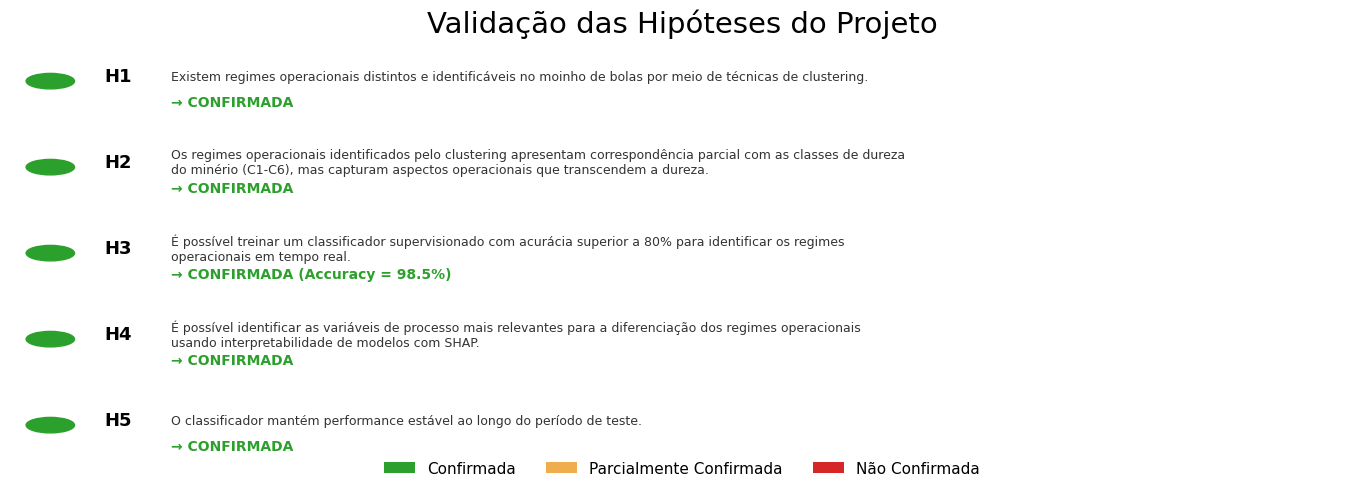

In [8]:
# ==============================================================================
# Quadro visual das hipóteses
# ==============================================================================
import matplotlib.patches as mpatches
import textwrap

fig, ax = plt.subplots(figsize=(14, 5))
ax.axis('off')

cor_resultado = {
    'CONFIRMADA': '#2ca02c',
    'PARCIALMENTE': '#f0ad4e',
    'NÃO': '#d62728'
}

y_positions = np.linspace(0.92, 0.12, len(hipoteses))

for i, (h, y) in enumerate(zip(hipoteses, y_positions)):
    cor = '#2ca02c'
    for key, c in cor_resultado.items():
        if key in h['resultado']:
            cor = c
            break

    circle = plt.Circle((0.03, y), 0.018, color=cor, transform=ax.transAxes)
    ax.add_patch(circle)

    ax.text(0.07, y + 0.01, h['id'], fontsize=13, fontweight='bold',
            transform=ax.transAxes, va='center')

    enunciado_wrapped = textwrap.fill(h['enunciado'], width=115)
    ax.text(0.12, y + 0.01, enunciado_wrapped, fontsize=9,
            transform=ax.transAxes, va='center', color='#333',
            linespacing=1.2)

    resultado_curto = h['resultado'].split('—')[0].strip() if '—' in h['resultado'] else h['resultado']
    ax.text(0.12, y - 0.05, f'→ {resultado_curto}', fontsize=10,
            transform=ax.transAxes, va='center', color=cor, fontweight='bold')

ax.set_title('Validação das Hipóteses do Projeto', fontsize=21, pad=10)

legend_elements = [
    mpatches.Patch(facecolor='#2ca02c', label='Confirmada'),
    mpatches.Patch(facecolor='#f0ad4e', label='Parcialmente Confirmada'),
    mpatches.Patch(facecolor='#d62728', label='Não Confirmada'),
]
ax.legend(handles=legend_elements, loc='lower center', ncol=3,
          fontsize=11, frameon=False, bbox_to_anchor=(0.5, -0.03))

plt.subplots_adjust(top=0.92, bottom=0.06, left=0.02, right=0.98)

fig.savefig(FIGURES_DIR / 'S3c_01_hipoteses_validacao.png', dpi=150, bbox_inches='tight')
salvar_imagem(STAGE, 'hipoteses_validacao', fig, 'S3c_01_hipoteses_validacao.png')
plt.show()


In [9]:
# ==============================================================================
# Resumo Final
# ==============================================================================

print("="*80)
print("PROJETO CONCLUÍDO")
print("="*80)
print()
print("Sprint 1: Preparação + EDA + Clustering → 3 regimes operacionais identificados")
print(f"Sprint 2: Classificador supervisionado → LightGBM {acc_test:.1%} accuracy")
print(f"Sprint 3: Validação cruzada + temporal + SHAP → {confirmadas}/5 hipóteses validadas")
print()
print("Artefatos:")
print(f"  - Figuras: {len(list(FIGURES_DIR.glob('*.png')))} em {FIGURES_DIR}")
print(f"  - Modelos: {len(list(MODELS_DIR.glob('*.pkl')))} em {MODELS_DIR}")
print(f"  - Dados: disco (Parquet/CSV) + PostgreSQL (schema otimizar_moagem_aura)")

PROJETO CONCLUÍDO

Sprint 1: Preparação + EDA + Clustering → 3 regimes operacionais identificados
Sprint 2: Classificador supervisionado → LightGBM 98.5% accuracy
Sprint 3: Validação cruzada + temporal + SHAP → 5/5 hipóteses validadas

Artefatos:
  - Figuras: 16 em C:\ScriptsDatamindsPIP\4-Projeto aplicado\figures\03_sprint3
  - Modelos: 9 em C:\ScriptsDatamindsPIP\4-Projeto aplicado\models
  - Dados: disco (Parquet/CSV) + PostgreSQL (schema otimizar_moagem_aura)


In [10]:
# ==============================================================================
# Exportar notebook para HTML
# ==============================================================================
from pathlib import Path
from IPython.display import display, Javascript
import time

display(Javascript("IPython.notebook.save_checkpoint()"))
time.sleep(3)

from nbconvert import HTMLExporter
import nbformat

_nb_path = Path(r"C:\ScriptsDatamindsPIP\4-Projeto aplicado\notebooks\03_sprint3\c_resultados_finais.ipynb")
_html_dir = Path(r"C:\ScriptsDatamindsPIP\4-Projeto aplicado\html")
_html_dir.mkdir(parents=True, exist_ok=True)

with open(_nb_path, encoding="utf-8") as _f:
    _nb_node = nbformat.read(_f, as_version=4)

_exporter = HTMLExporter()
_exporter.exclude_input = True
(_html_body, _) = _exporter.from_notebook_node(_nb_node)

_out_path = _html_dir / "c_resultados_finais.html"
_out_path.write_text(_html_body, encoding="utf-8")
print("HTML exportado:", _out_path)

<IPython.core.display.Javascript object>

HTML exportado: C:\ScriptsDatamindsPIP\4-Projeto aplicado\html\c_resultados_finais.html
